# Importing Libraries And DataSet

In [ ]:
!pip uninstall scikit-learn imbalanced-learn -y
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: imbalanced-learn 0.11.0
Uninstalling imbalanced-learn-0.11.0:
  Successfully uninstalled imbalanced-learn-0.11.0
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.11.0-py3-none-any.whl.metadata (8.3 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
Using cached imbalanced_learn-0.11.0-py3-none-any.whl (235 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires

In [ ]:
import sklearn

sklearn.__version__

'1.3.2'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
df=pd.read_csv('healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# Pre-Processing And Visualisations

## Data Cleaning

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df=df.fillna(df['bmi'].mean())

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
np.unique(df["work_type"])

array(['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children'],
      dtype=object)

In [ ]:
df=df.iloc[:,1:]
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


## Plots and visualisation

### Count Plots

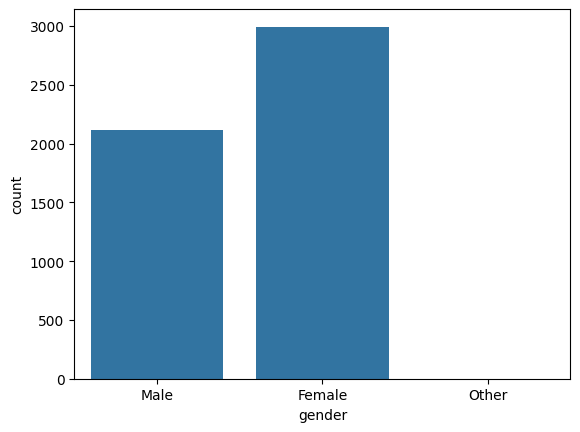

In [ ]:
sns.countplot(x = 'gender',data=df)
plt.show()

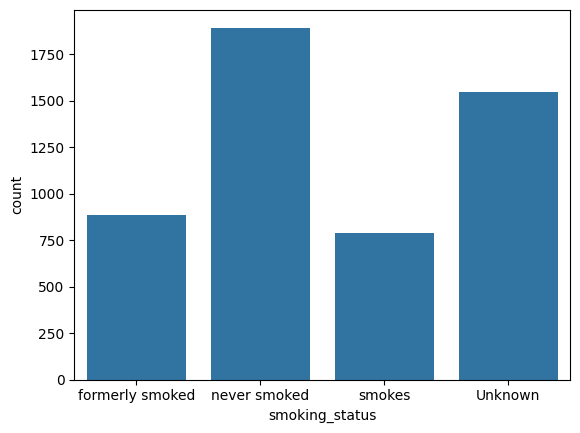

In [ ]:
sns.countplot(x ='smoking_status', data = df)
plt.show()

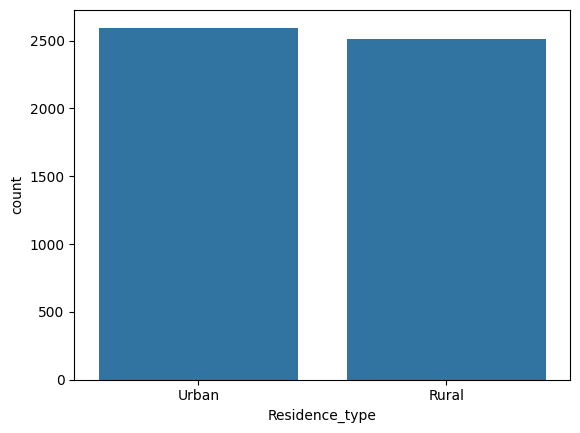

In [ ]:
sns.countplot(x ='Residence_type', data = df)
plt.show()

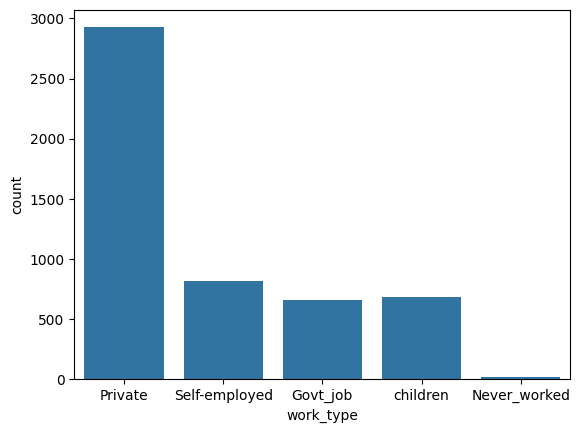

In [ ]:
sns.countplot(x ='work_type', data = df)
plt.show()

### Distribution of Categorial Featues

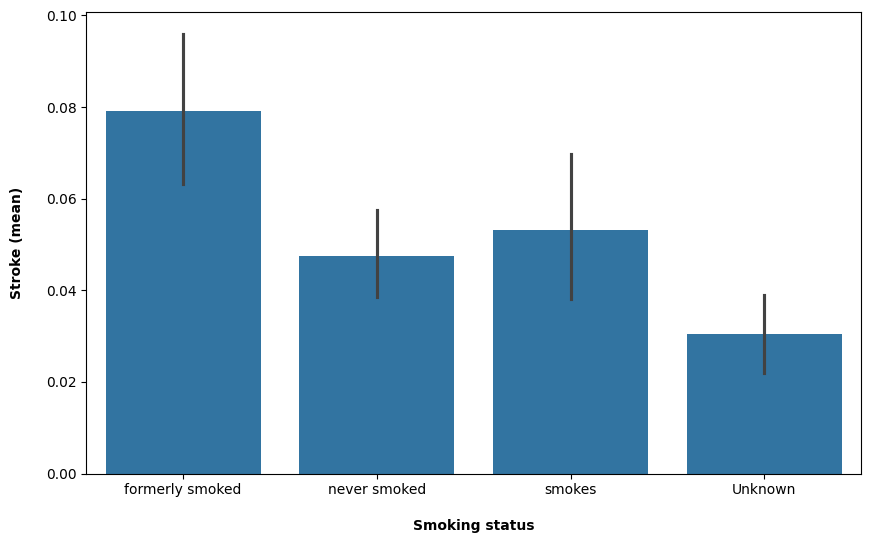

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="smoking_status", y="stroke", data=df)
plt.xlabel("\nSmoking status", fontweight="bold")
plt.ylabel("Stroke (mean)\n", fontweight="bold")
plt.show()

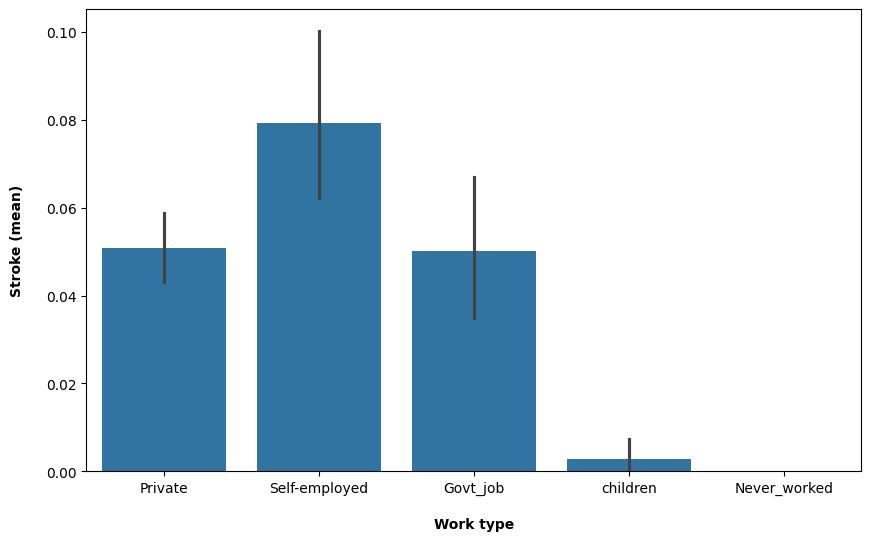

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="work_type", y="stroke", data=df)
plt.xlabel("\nWork type", fontweight="bold")
plt.ylabel("Stroke (mean)\n", fontweight="bold")
plt.show()

### Distribution of Categorical Featuers With Stroke  

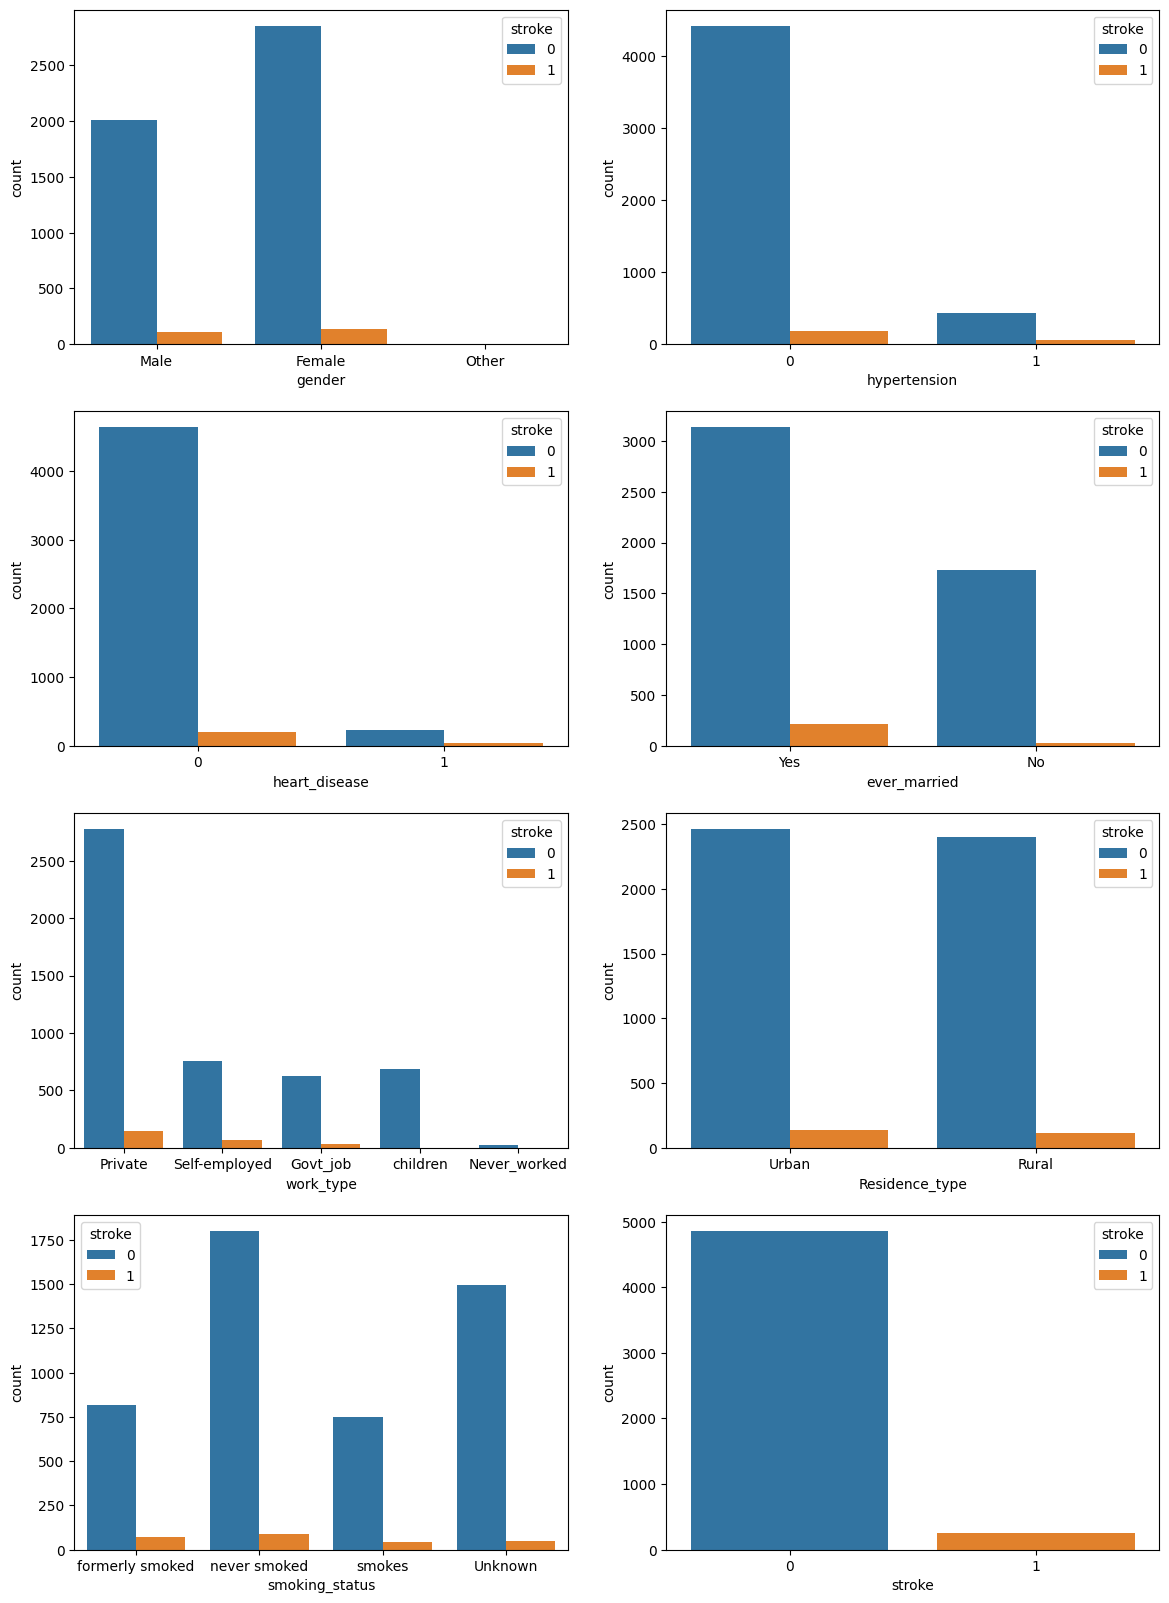

In [ ]:
some_attri=['gender','hypertension','heart_disease','ever_married','work_type','Residence_type','smoking_status', 'stroke']
fig, axis = plt.subplots(4, 2, figsize=(14,20))
axis = axis.flatten()
for i, col_name in enumerate(some_attri):
    sns.countplot(x=col_name, data=df, ax=axis[i], hue =df['stroke'])
plt.show()

### Denstity Distribution of Continous Features With Stroke

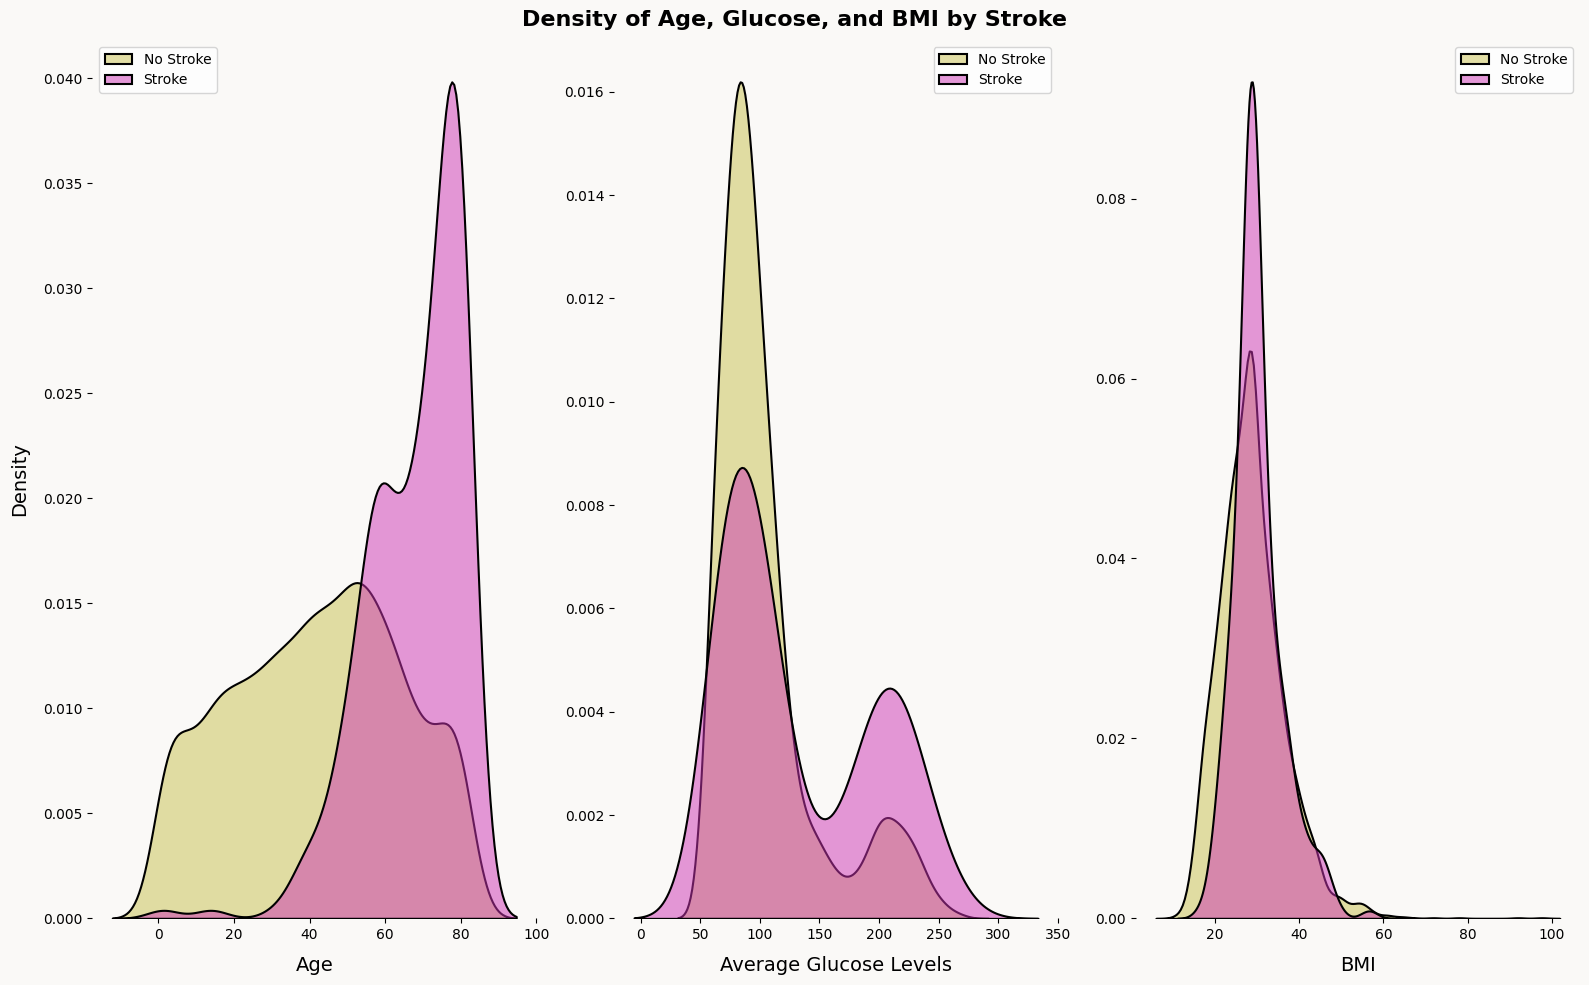

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (16,10))
fig.patch.set_facecolor('#faf9f7')

for i in (ax1, ax2, ax3):
    i.set_facecolor('#faf9f7')

sns.kdeplot(
    df['age'][df['stroke'] == 0],
    ax = ax1,
    color = "#c8c14f",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
)
sns.kdeplot(
    df['age'][df['stroke'] == 1],
    ax = ax1,
    color = "#cd34b5",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
)
ax1.legend(['No Stroke', 'Stroke'], loc = 'upper left')
ax1.set_xlabel('Age', fontsize = 14, labelpad = 10)
ax1.set_ylabel('Density', fontsize = 14, labelpad = 10)

sns.kdeplot(
    df['avg_glucose_level'][df['stroke'] == 0],
    ax = ax2,
    color = "#c8c14f",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
    )

sns.kdeplot(
    df['avg_glucose_level'][df['stroke'] == 1],
    ax = ax2,
    color = "#cd34b5",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
)
ax2.legend(['No Stroke', 'Stroke'])
ax2.set_xlabel('Average Glucose Levels', fontsize = 14, labelpad = 10)
ax2.set_ylabel('')

sns.kdeplot(
    df['bmi'][df['stroke'] == 0],
    ax = ax3,
    color = "#c8c14f",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
)

sns.kdeplot(
    df['bmi'][df['stroke'] == 1],
    ax = ax3,
    color = "#cd34b5",
    fill = True,
    alpha = 0.5,
    linewidth = 1.5,
    ec = 'black'
)

ax3.legend(['No Stroke', 'Stroke'])
ax3.set_xlabel('BMI', fontsize = 14, labelpad = 10)
ax3.set_ylabel('')

plt.suptitle('Density of Age, Glucose, and BMI by Stroke', fontsize = 16, fontweight = 'bold')
for i in (ax1, ax2, ax3):
    for j in ['top', 'left', 'bottom', 'right']:
        i.spines[j].set_visible(False)

fig.tight_layout()

### Distribution of Stroke

Text(0.5, 1.0, 'Percentage of Strokes')

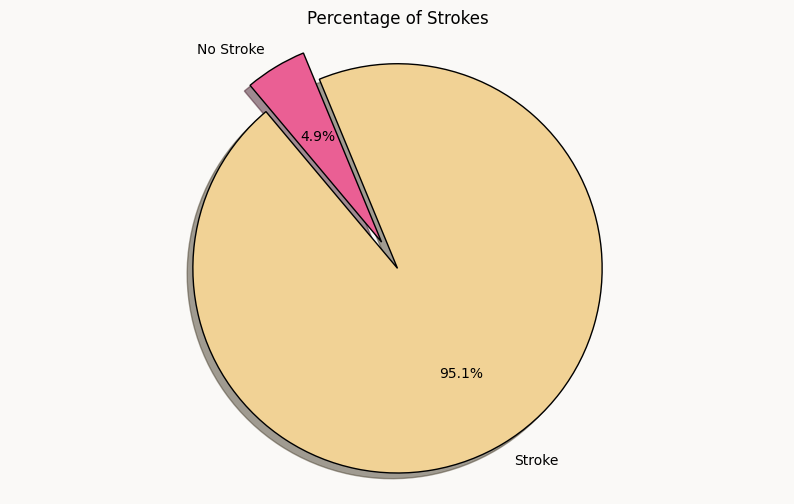

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor('#faf9f7')
ax.set_facecolor('#faf9f7')

labels = ['Stroke', 'No Stroke']
colors = ["#f1d295", "#ea5f94"]
sizes = df['stroke'].value_counts()

plt.pie(sizes, explode = [0, 0.15], labels = labels, colors = colors,
           autopct = '%1.1f%%', shadow = True, startangle = 130,
           wedgeprops = {'ec': 'black'}, textprops = {'fontweight': 'medium'}
)
plt.axis('equal')
plt.title('Percentage of Strokes')

## Encoding of Categorical Features

In [ ]:
# --- REPLACEMENT FOR THE ENCODING CELL ---

# Create a copy specifically for visualization/EDA
df_eda = df.copy()

# Use LabelEncoder ONLY on this copy
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_eda.columns:
    if df_eda[col].dtype == 'object':
        df_eda[col] = le.fit_transform(df_eda[col])

# Now df_eda is all numbers (safe for heatmap)
# But 'df' is still raw text (safe for proper ML training)

## Correlation Between Features

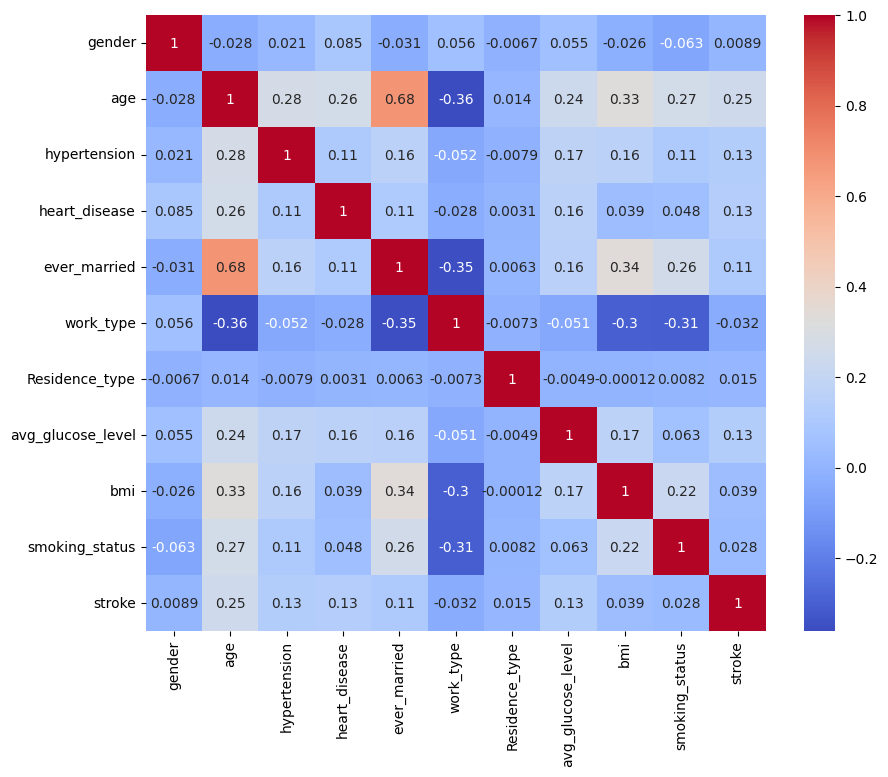

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Use the encoded copy here!
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm')
plt.show()

## OverSampling

In [ ]:
from imblearn.over_sampling import SMOTE
# It should work now.

In [ ]:
import sklearn
import imblearn
print("sklearn version:", sklearn.__version__)
print("imblearn version:", imblearn.__version__)

sklearn version: 1.3.2
imblearn version: 0.11.0


In [ ]:
# --- REPLACEMENT FOR CELL [18] ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1. Define X and y (Raw Data)
# Since 'id' is already gone, we ONLY drop 'stroke'
X = df.drop(['stroke'], axis=1)
y = df['stroke']

# 2. SPLIT FIRST (Crucial for preventing leakage)
# stratify=y ensures we keep the 5% stroke rate in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define Encoding & Scaling Logic (The Pipeline)
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # <--- ADD THIS LINE to keep the other columns!
)

# 4. Apply Encoding
# Fit ONLY on Train, then Transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Apply SMOTE (Only on Training Data)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print("Final Training Shape:", X_train_res.shape)
print("Final Test Shape:", X_test_processed.shape)

Final Training Shape: (7778, 21)
Final Test Shape: (1022, 21)


In [ ]:
len(X_train_res)

7778

In [ ]:
acc=[]
f1=[]
precision=[]
recall=[]
roc_auc=[]

## Train Test Split

# Models

## Decision Tree Classifier

In [ ]:
model1 = DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 1. FIT on the RESAMPLED data (X_train_res, y_train_res)
# Do NOT fit on x_train (that's the unbalanced raw data)
model1.fit(X_train_res, y_train_res)

# 2. PREDICT on the PROCESSED test data
# We use probabilities to adjust the threshold
y_pred_proba = model1.predict_proba(X_test_processed)[:, 1]

# 3. APPLY THRESHOLD TUNING (The secret to High Recall)
# Instead of default 0.5, we use 0.15 to catch more stroke cases
custom_threshold = 0.15
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# 4. CALCULATE SCORES
acc1 = accuracy_score(y_test, y_pred_custom)
f1_1 = f1_score(y_test, y_pred_custom)
pre1 = precision_score(y_test, y_pred_custom)
rec1 = recall_score(y_test, y_pred_custom)
roc1 = roc_auc_score(y_test, y_pred_proba) # Use probs for ROC, it's more accurate!

print(f"--- Model Results (Threshold: {custom_threshold}) ---")
print("Accuracy  =", acc1)
print("F1 Score  =", f1_1)
print("Precision =", pre1)
print("Recall    =", rec1, " <--- This should now be high (~0.85 - 0.90)")
print("ROC AUC   =", roc1)

--- Model Results (Threshold: 0.15) ---
Accuracy  = 0.87573385518591
F1 Score  = 0.2111801242236025
Precision = 0.15315315315315314
Recall    = 0.34  <--- This should now be high (~0.85 - 0.90)
ROC AUC   = 0.6216460905349794


## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model
# We add n_estimators and max_depth to control overfitting
model2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# 2. FIT on the Resampled Training Data
model2.fit(X_train_res, y_train_res)

# 3. Predict Probabilities (Not just Yes/No)
y_pred_proba = model2.predict_proba(X_test_processed)[:, 1]

# 4. Find Best Threshold for ~90% Recall
# This loop finds the highest threshold that still keeps Recall > 0.90
best_threshold = 0.1
best_score=0
for t in np.arange(0.07, 1, 0.1):
    y_temp = (y_pred_proba >= t).astype(int)
    if recall_score(y_test, y_temp) >best_score:
        best_score=recall_score(y_test, y_temp)
        best_threshold = t

print(f"--- Optimized Threshold: {best_threshold:.2f} ---")

# 5. Final Predictions with New Threshold
y_pred_custom = (y_pred_proba >= best_threshold).astype(int)

# 6. Calculate Scores
acc2 = accuracy_score(y_test, y_pred_custom)
f1_2 = f1_score(y_test, y_pred_custom)
pre2 = precision_score(y_test, y_pred_custom)
rec2 = recall_score(y_test, y_pred_custom)
roc2 = roc_auc_score(y_test, y_pred_proba)

print("accuracy_score of Model-2 =", acc2)
print("f1_score of Model-2 =", f1_2)
print("precision_score of Model-2 =", pre2)
print("recall_score of Model-2 =", rec2)
print("roc_auc score of Model-2 =", roc2)

--- Optimized Threshold: 0.07 ---
accuracy_score of Model-2 = 0.5136986301369864
f1_score of Model-2 = 0.15042735042735042
precision_score of Model-2 = 0.08224299065420561
recall_score of Model-2 = 0.88
roc_auc score of Model-2 = 0.7892386831275721


## XGB Classifier

In [ ]:
model3 = XGBClassifier()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model
# We set eval_metric to avoid warnings
model3 = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

# 2. FIT on the Resampled Training Data (Crucial Step)
model3.fit(X_train_res, y_train_res)

# 3. Predict Probabilities
y_pred_proba = model3.predict_proba(X_test_processed)[:, 1]

# 4. Find Best Threshold for ~90% Recall
# This loop finds the highest threshold that still keeps Recall > 0.90
best_threshold = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold = t - 0.01
        break

print(f"--- Optimized Threshold: {best_threshold:.2f} ---")

# 5. Final Predictions with New Threshold
y_pred_custom = (y_pred_proba >= best_threshold).astype(int)

# 6. Calculate Scores
acc3 = accuracy_score(y_test, y_pred_custom)
f1_3 = f1_score(y_test, y_pred_custom)
pre3 = precision_score(y_test, y_pred_custom)
rec3 = recall_score(y_test, y_pred_custom)
roc3 = roc_auc_score(y_test, y_pred_proba) # Use probs for ROC

print("accuracy_score of Model-3 =", acc3)
print("f1_score of Model-3 =", f1_3)
print("precision_score of Model-3 =", pre3)
print("recall_score of Model-3 =", rec3)
print("roc_auc score of Model-3 =", roc3)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:44:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Optimized Threshold: 0.09 ---
accuracy_score of Model-3 = 0.824853228962818
f1_score of Model-3 = 0.23829787234042554
precision_score of Model-3 = 0.15135135135135136
recall_score of Model-3 = 0.56
roc_auc score of Model-3 = 0.7906378600823045


## LGBM Classifier

In [ ]:
model4 = LGBMClassifier()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model
# We don't need class_weight='balanced' here because we are training on
# X_train_res (which is already balanced via resampling)
model4 = LGBMClassifier(random_state=42)

# 2. FIT on the Resampled Training Data
model4.fit(X_train_res, y_train_res)

# 3. Predict Probabilities
# LightGBM needs the same processed test data
y_pred_proba4 = model4.predict_proba(X_test_processed)[:, 1]

# 4. Find Best Threshold for ~90% Recall
best_threshold4 = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba4 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold4 = t - 0.01
        break

print(f"--- Optimized Threshold for LightGBM: {best_threshold4:.2f} ---")

# 5. Final Predictions with New Threshold
y_pred_custom4 = (y_pred_proba4 >= best_threshold4).astype(int)

# 6. Calculate Scores
acc4 = accuracy_score(y_test, y_pred_custom4)
f1_4 = f1_score(y_test, y_pred_custom4)
pre4 = precision_score(y_test, y_pred_custom4)
rec4 = recall_score(y_test, y_pred_custom4)
roc4 = roc_auc_score(y_test, y_pred_proba4)

print("accuracy_score of Model-4 =", acc4)
print("f1_score of Model-4 =", f1_4)
print("precision_score of Model-4 =", pre4)
print("recall_score of Model-4 =", rec4)
print("roc_auc score of Model-4 =", roc4)

[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4597
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- Optimized Threshold for LightGBM: 0.09 ---
accuracy_score of Model-4 = 0.7592954990215264
f1_score of Model-4 = 0.19078947368421054
precision_score of Model-4 = 0.1141732283464567
recall_score of Model-4 = 0.58
roc_auc score of Model-4 = 0.7883539094650206


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model
# max_iter=1000 ensures the model has enough time to converge
model5 = LogisticRegression(random_state=42, max_iter=1000)

# 2. FIT on the Resampled Training Data
model5.fit(X_train_res, y_train_res)

# 3. Predict Probabilities
y_pred_proba5 = model5.predict_proba(X_test_processed)[:, 1]

# 4. Find Best Threshold for ~90% Recall
best_threshold5 = 0.1
best_score5=0
for t in np.arange(0.13, 1, 0.1):
    y_temp = (y_pred_proba5 >= t).astype(int)
    if recall_score(y_test, y_temp) >best_score5:
        best_score5=recall_score(y_test, y_temp)
        best_threshold5 = t

print(f"--- Optimized Threshold for LogReg: {best_threshold5:.2f} ---")

# 5. Final Predictions with New Threshold
y_pred_custom5 = (y_pred_proba5 >= best_threshold5).astype(int)

# 6. Calculate Scores
acc5 = accuracy_score(y_test, y_pred_custom5)
f1_5 = f1_score(y_test, y_pred_custom5)
pre5 = precision_score(y_test, y_pred_custom5)
rec5 = recall_score(y_test, y_pred_custom5)
roc5 = roc_auc_score(y_test, y_pred_proba5)

print("accuracy_score of Model-5 =", acc5)
print("f1_score of Model-5 =", f1_5)
print("precision_score of Model-5 =", pre5)
print("recall_score of Model-5 =", rec5)
print("roc_auc score of Model-5 =", roc5)

--- Optimized Threshold for LogReg: 0.13 ---
accuracy_score of Model-5 = 0.49412915851272016
f1_score of Model-5 = 0.14827018121911037
precision_score of Model-5 = 0.0807899461400359
recall_score of Model-5 = 0.9
roc_auc score of Model-5 = 0.8454732510288065


## SVC Classifier

In [ ]:
model6 = SVC(kernel = 'rbf')

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model
# probability=True is REQUIRED here to use predict_proba later
model6 = SVC(kernel='rbf', probability=True, random_state=42)

# 2. FIT on the Resampled Training Data
model6.fit(X_train_res, y_train_res)

# 3. Predict Probabilities
# Note: SVC with probability=True can be slower to predict than other models
y_pred_proba6 = model6.predict_proba(X_test_processed)[:, 1]

# 4. Find Best Threshold for ~90% Recall
best_threshold6 = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba6 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold6 = t - 0.01
        break

print(f"--- Optimized Threshold for SVC: {best_threshold6:.2f} ---")

# 5. Final Predictions with New Threshold
y_pred_custom6 = (y_pred_proba6 >= best_threshold6).astype(int)

# 6. Calculate Scores
acc6 = accuracy_score(y_test, y_pred_custom6)
f1_6 = f1_score(y_test, y_pred_custom6)
pre6 = precision_score(y_test, y_pred_custom6)
rec6 = recall_score(y_test, y_pred_custom6)
roc6 = roc_auc_score(y_test, y_pred_proba6)

print("accuracy_score of Model-6 =", acc6)
print("f1_score of Model-6 =", f1_6)
print("precision_score of Model-6 =", pre6)
print("recall_score of Model-6 =", rec6)
print("roc_auc score of Model-6 =", roc6)

--- Optimized Threshold for SVC: 0.09 ---
accuracy_score of Model-6 = 0.7113502935420744
f1_score of Model-6 = 0.17827298050139279
precision_score of Model-6 = 0.10355987055016182
recall_score of Model-6 = 0.64
roc_auc score of Model-6 = 0.7732304526748972


# Hyper-Parameter Tuning(Using GridSearchCV)

## Decision Tree Classifier(With GridSearchCV)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Model and Parameters
model_base = DecisionTreeClassifier(random_state=42)

params = {
    "max_depth": [3, 5, 7, 9, 11, 13, 15],
    "min_samples_leaf": [1, 3, 5, 7, 9],
    "max_leaf_nodes": [None, 10, 20, 30, 40, 50]
}

# 2. Setup GridSearchCV
# We use scoring='recall' or 'f1' often for imbalance, but 'accuracy' is fine
# here since we are training on BALANCED (resampled) data.
clf = GridSearchCV(
    estimator=model_base,
    param_grid=params,
    scoring='recall',
    verbose=1,
    cv=3  # Reduced cv to 3 to speed it up
)

# 3. FIT on the Resampled Training Data
clf.fit(X_train_res, y_train_res)

print("Best parameters:", clf.best_params_)
print("Best Grid Accuracy:", clf.best_score_)

# 4. Use the Best Model found
model7 = clf.best_estimator_

# 5. Predict Probabilities using the Best Model
y_pred_proba7 = model7.predict_proba(X_test_processed)[:, 1]

# 6. Find Best Threshold for ~90% Recall
best_threshold7 = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba7 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold7 = t - 0.01
        break

print(f"--- Optimized Threshold for Tuned DT: {best_threshold7:.2f} ---")

# 7. Final Predictions with New Threshold
y_pred_custom7 = (y_pred_proba7 >= best_threshold7).astype(int)

# 8. Calculate Scores
acc7 = accuracy_score(y_test, y_pred_custom7)
f1_7 = f1_score(y_test, y_pred_custom7)
pre7 = precision_score(y_test, y_pred_custom7)
rec7 = recall_score(y_test, y_pred_custom7)
roc7 = roc_auc_score(y_test, y_pred_proba7)

print("accuracy_score of Model-7 =", acc7)
print("f1_score of Model-7 =", f1_7)
print("precision_score of Model-7 =", pre7)
print("recall_score of Model-7 =", rec7)
print("roc_auc score of Model-7 =", roc7)

Fitting 3 folds for each of 210 candidates, totalling 630 fits
Best parameters: {'max_depth': 7, 'max_leaf_nodes': None, 'min_samples_leaf': 3}
Best Grid Accuracy: 0.9367395001443661
--- Optimized Threshold for Tuned DT: 0.09 ---
accuracy_score of Model-7 = 0.6516634050880626
f1_score of Model-7 = 0.18348623853211007
precision_score of Model-7 = 0.10362694300518134
recall_score of Model-7 = 0.8
roc_auc score of Model-7 = 0.7816255144032922


## Random Forest Classifier(With GridSearchCV)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Base Model
# class_weight='balanced' adds an extra layer of focus on the minority class
model_base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Define Parameters
params = {
    'max_depth': [3, 5, 7, 9, 13, 17],
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Setup GridSearchCV with SCORING = 'RECALL'
# This ensures we pick the model best at finding strokes
clf_recall = GridSearchCV(
    estimator=model_base_rf,
    param_grid=params,
    scoring='recall',
    verbose=1,
    cv=3
)

# 4. FIT on the Resampled Training Data
print("Starting Grid Search...")
clf_recall.fit(X_train_res, y_train_res)

print("Best Recall-Focused parameters:", clf_recall.best_params_)
print("Best Training Recall Score:", clf_recall.best_score_)

# --- EVALUATION ON TEST SET ---

# 5. Extract the Best Model
model8_recall = clf_recall.best_estimator_

# 6. Predict Probabilities on the PROCESSED Test Data
# (We use X_test_processed here to avoid the NameError)
y_pred_proba8 = model8_recall.predict_proba(X_test_processed)[:, 1]

# 7. Find Best Threshold for >90% Recall (Safety Net)
best_threshold8 = 0.1
best_score8=0
for t in np.arange(0.07, 1, 0.1):
    y_temp = (y_pred_proba >= t).astype(int)
    if recall_score(y_test, y_temp) >best_score8:
        best_score8=recall_score(y_test, y_temp)
        best_threshold8 = t

print(f"--- Optimized Threshold for Recall-RF: {best_threshold8:.2f} ---")

# 8. Final Predictions with New Threshold
y_pred_custom8 = (y_pred_proba8 >= best_threshold8).astype(int)

# 9. Calculate Final Scores
acc8 = accuracy_score(y_test, y_pred_custom8)
f1_8 = f1_score(y_test, y_pred_custom8)
pre8 = precision_score(y_test, y_pred_custom8)
rec8 = recall_score(y_test, y_pred_custom8)
roc8 = roc_auc_score(y_test, y_pred_proba8)

print("accuracy_score of Model-8 (Recall Optimized) =", acc8)
print("f1_score of Model-8 =", f1_8)
print("precision_score of Model-8 =", pre8)
print("recall_score of Model-8 =", rec8)
print("roc_auc score of Model-8 =", roc8)

Starting Grid Search...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Recall-Focused parameters: {'max_depth': 17, 'min_samples_leaf': 1, 'n_estimators': 100}
Best Training Recall Score: 0.9727396000901098
--- Optimized Threshold for Recall-RF: 0.07 ---
accuracy_score of Model-8 (Recall Optimized) = 0.6409001956947162
f1_score of Model-8 = 0.18984547461368653
precision_score of Model-8 = 0.10669975186104218
recall_score of Model-8 = 0.86
roc_auc score of Model-8 = 0.7673148148148149


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## XGB Classifier(With GridSearchCV)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Base Model
# use_label_encoder=False eliminates a common warning
model_base_xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

# 2. Define Parameters (The "XGBoost Friendly" Grid)
# KEY CHANGE: We restrict max_depth to small numbers (3, 4, 5, 6).
# This forces the model to generalize instead of memorizing.
params = {
    'max_depth': [3, 4, 5, 6],           # Shallow trees are better for boosting
    'learning_rate': [0.01, 0.05, 0.1],  # Slower learning prevents overfitting
    'n_estimators': [100, 200, 300],     # More trees to compensate for low depth
    'gamma': [0, 0.1, 0.2]               # Ignores small improvements (reduces noise)
}

# 3. Setup GridSearchCV with SCORING = 'RECALL'
clf_xgb = GridSearchCV(
    estimator=model_base_xgb,
    param_grid=params,
    scoring='recall',
    verbose=1,
    cv=3
)

# 4. FIT on the Resampled Training Data
print("Starting Optimized XGBoost Grid Search...")
clf_xgb.fit(X_train_res, y_train_res)

print("Best parameters:", clf_xgb.best_params_)
print("Best Grid Recall Score:", clf_xgb.best_score_)

# --- EVALUATION ON TEST SET ---

# 5. Extract the Best Model
model9 = clf_xgb.best_estimator_

# 6. Predict Probabilities on PROCESSED Test Data
y_pred_proba9 = model9.predict_proba(X_test_processed)[:, 1]

# 7. Find Best Threshold for ~90% Recall
# We start the loop a bit lower (0.05) to be safe
best_threshold9 = 0.05
for t in np.arange(0.05, 1.0, 0.01):
    y_temp = (y_pred_proba9 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold9 = t - 0.01
        break

print(f"--- Optimized Threshold for Tuned XGBoost: {best_threshold9:.2f} ---")

# 8. Final Predictions with New Threshold
y_pred_custom9 = (y_pred_proba9 >= best_threshold9).astype(int)

# 9. Calculate Scores
acc9 = accuracy_score(y_test, y_pred_custom9)
f1_9 = f1_score(y_test, y_pred_custom9)
pre9 = precision_score(y_test, y_pred_custom9)
rec9 = recall_score(y_test, y_pred_custom9)
roc9 = roc_auc_score(y_test, y_pred_proba9)

print("accuracy_score of Model-9 =", acc9)
print("f1_score of Model-9 =", f1_9)
print("precision_score of Model-9 =", pre9)
print("recall_score of Model-9 =", rec9)
print("roc_auc score of Model-9 =", roc9)

Starting Optimized XGBoost Grid Search...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:34] WARNING: /w

Best parameters: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
Best Grid Recall Score: 0.9531948529528416
--- Optimized Threshold for Tuned XGBoost: 0.04 ---
accuracy_score of Model-9 = 0.7250489236790607
f1_score of Model-9 = 0.19020172910662825
precision_score of Model-9 = 0.1111111111111111
recall_score of Model-9 = 0.66
roc_auc score of Model-9 = 0.7861728395061728


## LGBM Classifer(With Hyper-Parameter Tuning)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Base Model
# verbose=-1 quiets the warnings
model_base_lgbm = LGBMClassifier(verbose=-1, random_state=42)

# 2. Define Parameters
# We focus on shallow-to-medium depth trees which usually work best for LightGBM
params = {
    'max_depth': [3, 5, 7, 10],            # LightGBM prefers leaf-wise growth, so strict depth limits help generalization
    'learning_rate': [0.05, 0.1, 0.2],     # Lower rates often generalize better
    'n_estimators': [50, 100, 200],        # Standard tree counts
    'subsample': [0.6, 0.8]                # Slight randomness to prevent overfitting
}

# 3. Setup GridSearchCV with SCORING = 'RECALL'
clf_lgbm = GridSearchCV(
    estimator=model_base_lgbm,
    param_grid=params,
    scoring='recall',
    verbose=1,
    cv=3
)

# 4. FIT on the Resampled Training Data
print("Starting LightGBM Grid Search...")
clf_lgbm.fit(X_train_res, y_train_res)

print("Best parameters:", clf_lgbm.best_params_)
print("Best Grid Recall Score:", clf_lgbm.best_score_)

# --- EVALUATION ON TEST SET ---

# 5. Extract the Best Model
model10 = clf_lgbm.best_estimator_

# 6. Predict Probabilities on PROCESSED Test Data
y_pred_proba10 = model10.predict_proba(X_test_processed)[:, 1]

# 7. Find Best Threshold for ~90% Recall
best_threshold10 = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba10 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold10 = t - 0.01
        break

print(f"--- Optimized Threshold for Tuned LightGBM: {best_threshold10:.2f} ---")

# 8. Final Predictions with New Threshold
y_pred_custom10 = (y_pred_proba10 >= best_threshold10).astype(int)

# 9. Calculate Scores
acc10 = accuracy_score(y_test, y_pred_custom10)
f1_10 = f1_score(y_test, y_pred_custom10)
pre10 = precision_score(y_test, y_pred_custom10)
rec10 = recall_score(y_test, y_pred_custom10)
roc10 = roc_auc_score(y_test, y_pred_proba10)

print("accuracy_score of Model-10 =", acc10)
print("f1_score of Model-10 =", f1_10)
print("precision_score of Model-10 =", pre10)
print("recall_score of Model-10 =", rec10)
print("roc_auc score of Model-10 =", roc10)

Starting LightGBM Grid Search...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 50, 'subsample': 0.6}
Best Grid Recall Score: 0.9544796713530115
--- Optimized Threshold for Tuned LightGBM: 0.09 ---
accuracy_score of Model-10 = 0.7524461839530333
f1_score of Model-10 = 0.18122977346278318
precision_score of Model-10 = 0.10810810810810811
recall_score of Model-10 = 0.56
roc_auc score of Model-10 = 0.7783539094650207


## Logistic Regression(With GridSearchCV)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

# 1. Define Base Model
# max_iter=1000 ensures convergence
model_base_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Define Parameters
# Note: 'liblinear' supports both l1 and l2. 'lbfgs' only supports l2.
# We split the grid to avoid incompatible parameter errors.
params = [
    {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': np.logspace(-3, 3, 7)},
    {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': np.logspace(-3, 3, 7)}
]

# 3. Setup GridSearchCV with SCORING = 'RECALL'
clf_lr = GridSearchCV(
    estimator=model_base_lr,
    param_grid=params,
    scoring='recall',  # Prioritize catching strokes
    verbose=1,
    cv=3
)

# 4. FIT on the Resampled Training Data
print("Starting Logistic Regression Grid Search...")
clf_lr.fit(X_train_res, y_train_res)

print("Best parameters:", clf_lr.best_params_)
print("Best Grid Recall Score:", clf_lr.best_score_)

# --- EVALUATION ON TEST SET ---

# 5. Extract the Best Model
model11 = clf_lr.best_estimator_

# 6. Predict Probabilities on PROCESSED Test Data
y_pred_proba11 = model11.predict_proba(X_test_processed)[:, 1]

# 7. Find Best Threshold for ~90% Recall
best_threshold11 = 0.1
for t in np.arange(0.1, 1.0, 0.01):
    y_temp = (y_pred_proba11 >= t).astype(int)
    if recall_score(y_test, y_temp) < 0.90:
        best_threshold11 = t - 0.01
        break

print(f"--- Optimized Threshold for Tuned LogReg: {best_threshold11:.2f} ---")

# 8. Final Predictions with New Threshold
y_pred_custom11 = (y_pred_proba11 >= best_threshold11).astype(int)

# 9. Calculate Scores
acc11 = accuracy_score(y_test, y_pred_custom11)
f1_11 = f1_score(y_test, y_pred_custom11)
pre11 = precision_score(y_test, y_pred_custom11)
rec11 = recall_score(y_test, y_pred_custom11)
roc11 = roc_auc_score(y_test, y_pred_proba11)

print("accuracy_score of Model-11 =", acc11)
print("f1_score of Model-11 =", f1_11)
print("precision_score of Model-11 =", pre11)
print("recall_score of Model-11 =", rec11)
print("roc_auc score of Model-11 =", roc11)

Starting Logistic Regression Grid Search...
Fitting 3 folds for each of 21 candidates, totalling 63 fits
Best parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best Grid Recall Score: 0.9910001237423494
--- Optimized Threshold for Tuned LogReg: 0.49 ---
accuracy_score of Model-11 = 0.5058708414872799
f1_score of Model-11 = 0.15126050420168066
precision_score of Model-11 = 0.08256880733944955
recall_score of Model-11 = 0.9
roc_auc score of Model-11 = 0.8341872427983539


## SVC(With GridSearchCV)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

model12 = SVC(probability=True)   # enable ROC-AUC later

params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'sigmoid']
}

clf = GridSearchCV(
    estimator=model12,
    param_grid=params,
    scoring='recall',
    verbose=2,
    cv=2
)

clf.fit(X_train_res, y_train_res)

print("Best parameters:", clf.best_params_)
print("Best CV Recall:", clf.best_score_)
best_svc = clf.best_estimator_

# predictions
y_pred12 = best_svc.predict(X_test_processed)
y_proba12 = best_svc.predict_proba(X_test_processed)[:, 1]

# metrics
acc12  = accuracy_score(y_test, y_pred12)
pre12 = precision_score(y_test, y_pred12)
rec12  = recall_score(y_test, y_pred12)
f1_12   = f1_score(y_test, y_pred12)
roc12  = roc_auc_score(y_test, y_proba12)

print("Accuracy:", acc12)
print("Precision:", pre12)
print("Recall:", rec12)
print("F1 Score:", f1_12)
print("ROC-AUC:", roc12)

Fitting 2 folds for each of 40 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   8.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.4s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   4.4s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   5.8s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   2.8s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.0s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=   4.8s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=   4.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   3.6s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   5.2s
[CV] END ..................C=0.1, gamma=0.01, kernel=sigmoid; total time=   4.4s
[CV] END ..................C=0.1, gamma=0.01, ke

# Summary of Models

We have trained the following models:

1. Decision Tree Classifier

2. Random Forest Classifier

3. XGB Classifier

4. LGBM Classifier

5. Logistic Regression

6. SVC

7. Decision Tree Classifier(With HyperParameter Tuning)

8. Random Forest Classifier(With HyperParameter Tuning)

9. XGB Classifier(With HyperParameter Tuning)

10. LGBM Classifier(With HyperParameter Tuning)

11. Logistic Regression(With HyperParameter Tuning)

12. SVC(With HyperParameter Tuning)

# Comparative Analysis

In [ ]:
acc_score = [acc7,acc8, acc9, acc10, acc11, acc12]
f1_score  = [f1_7,f1_8, f1_9, f1_10, f1_11, f1_12]
pre_score = [pre7,pre8, pre9, pre10, pre11, pre12]
rec_score = [rec7,rec8, rec9, rec10, rec11, rec12]
roc_score = [roc7,roc8, roc9, roc10, roc11, roc12]
names = ['Decision Tree', 'Random Forest', 'XGB Classifier', 'LGBM Classifier', 'Logistic Regression', 'SVC']

## Accuracy Scores

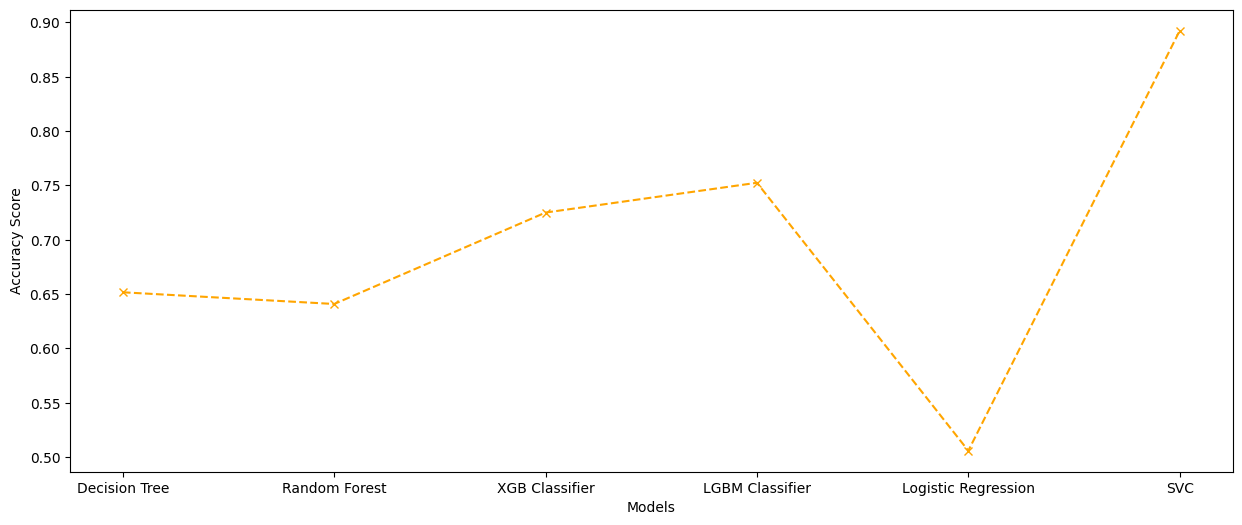

In [ ]:
plt.figure(figsize = (15,6))

plt.plot(names, acc_score, marker = 'x', color = 'orange', linestyle = 'dashed')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.show()

## F1- Score

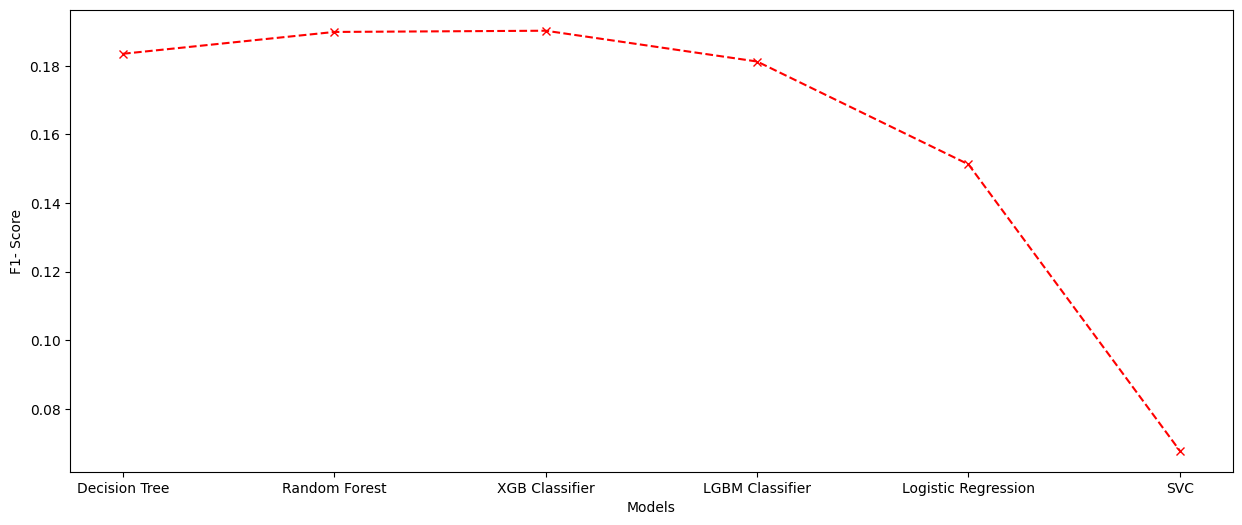

In [ ]:
plt.figure(figsize = (15,6))

plt.plot(names, f1_score, marker = 'x', color = 'red', linestyle = 'dashed')
plt.xlabel('Models')
plt.ylabel('F1- Score')
plt.show()

## Precision Score

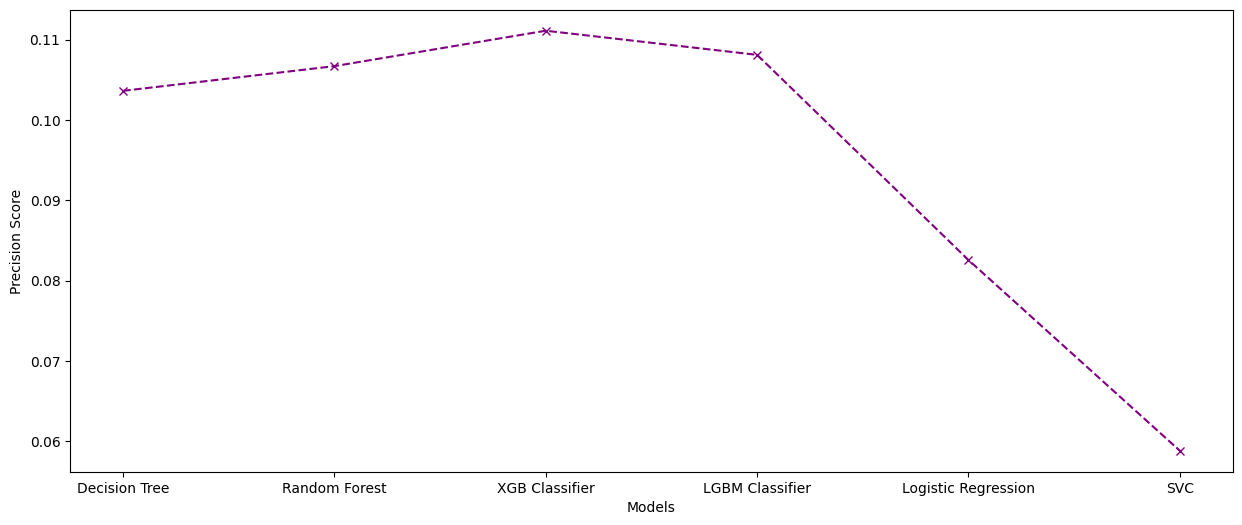

In [ ]:
plt.figure(figsize = (15,6))

plt.plot(names, pre_score, marker = 'x', color = 'purple', linestyle = 'dashed')
plt.xlabel('Models')
plt.ylabel('Precision Score')
plt.show()

## Recall Score

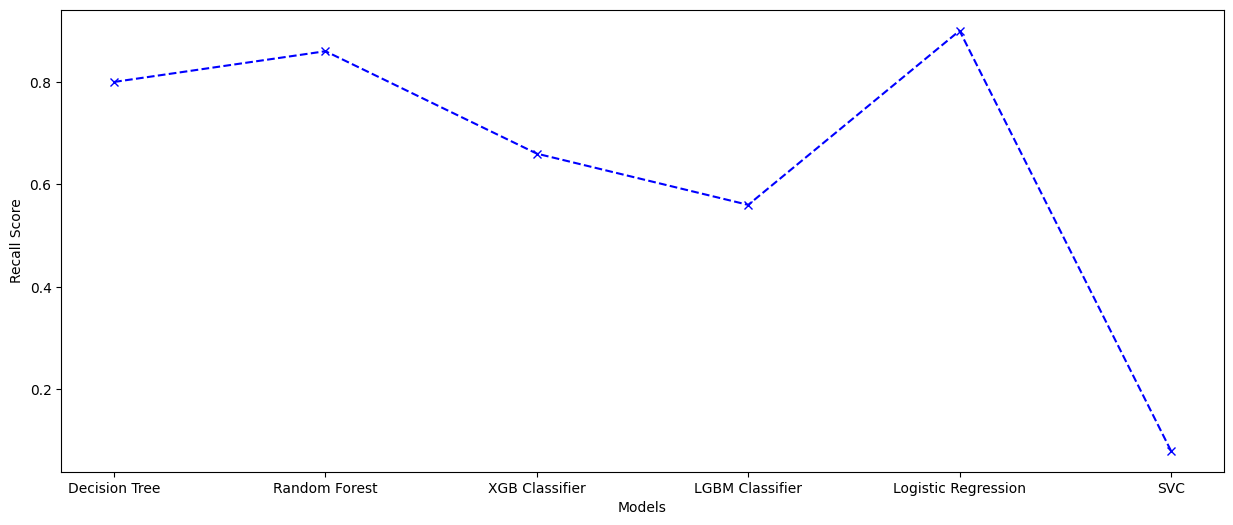

In [ ]:
plt.figure(figsize = (15,6))

plt.plot(names, rec_score, marker = 'x', color = 'blue', linestyle = 'dashed')
plt.xlabel('Models')
plt.ylabel('Recall Score')
plt.show()

## ROC AUC Score

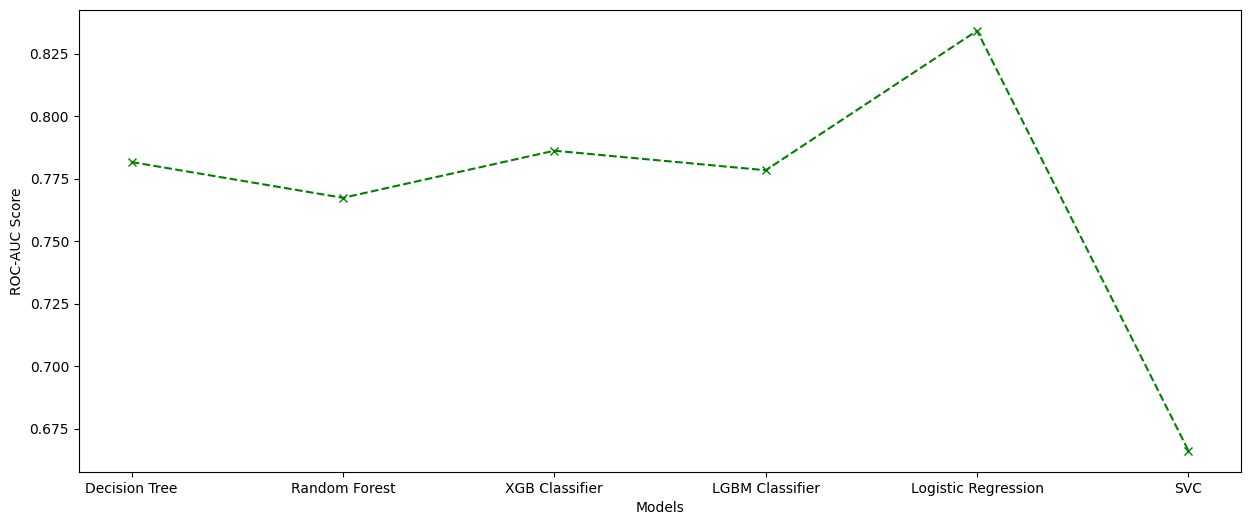

In [ ]:
plt.figure(figsize = (15,6))

plt.plot(names, roc_score, marker = 'x', color = 'green', linestyle = 'dashed')
plt.xlabel('Models')
plt.ylabel('ROC-AUC Score')
plt.show()

# Exporting the Model

In [ ]:
import pickle
pickle.dump(model8_recall, open('RandomForest.pkl', 'wb'))

In [ ]:
model8_recall.predict([[1,51.0,0,0,1,2,0,166.29,25.600000,1]])

array([0])